# AdaBoost bonus task: linear weak classifiers on fixed directions

Implements AdaBoost where weak classifiers are linear:
$h(x)=\mathrm{sign}(w^\top x + b)$, with $\|w\|=1$ and $w$ restricted to directions $0^\circ,5^\circ,\dots,355^\circ$.

For each direction we pick the best bias $b$ by minimizing **weighted** classification error.

Labels are in $\{-1,+1\}$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sign_pm1(x: np.ndarray) -> np.ndarray:
    # Sign returning values in {-1,+1}, using +1 for zeros.
    return np.where(x >= 0, 1, -1).astype(int)

def make_directions(step_deg: int = 5) -> np.ndarray:
    # Unit vectors for angles 0..355 degrees. Returns shape (2, K).
    angles = np.deg2rad(np.arange(0, 360, step_deg))
    return np.stack([np.cos(angles), np.sin(angles)], axis=0)

def best_bias_for_direction(X: np.ndarray, y: np.ndarray, D: np.ndarray, w: np.ndarray):
    '''
    X: (2,N), y: (N,) in {-1,+1}, D: (N,) weights (sum=1), w: (2,) unit vector.
    Finds bias b minimizing weighted error of sign(w^T x + b).
    Returns (b_best, err_best, preds_best).
    '''
    s = (w.reshape(1,2) @ X).ravel()  # projections, (N,)

    order = np.argsort(s)
    s_sorted = s[order]
    y_sorted = y[order]
    D_sorted = D[order]

    pos = (y_sorted == 1)
    neg = ~pos

    cum_pos = np.concatenate([[0.0], np.cumsum(D_sorted * pos)])
    cum_neg = np.concatenate([[0.0], np.cumsum(D_sorted * neg)])
    total_pos = cum_pos[-1]
    total_neg = cum_neg[-1]

    # threshold index i means t is between s_sorted[i-1] and s_sorted[i]
    i = np.arange(0, s_sorted.size + 1)
    pos_left = cum_pos[i]
    neg_left = cum_neg[i]
    pos_right = total_pos - pos_left
    neg_right = total_neg - neg_left

    # predict +1 on the right (s >= t), -1 on the left (s < t)
    err = pos_left + neg_right

    best_i = int(np.argmin(err))
    err_best = float(err[best_i])

    if best_i == 0:
        t = s_sorted[0] - 1e-12
    elif best_i == s_sorted.size:
        t = s_sorted[-1] + 1e-12
    else:
        t = 0.5 * (s_sorted[best_i - 1] + s_sorted[best_i])

    b_best = -float(t)
    preds_best = sign_pm1(s + b_best)
    return b_best, err_best, preds_best

def find_best_weak_linear(X: np.ndarray, y: np.ndarray, D: np.ndarray, W: np.ndarray):
    # Search over all directions (columns of W: (2,K)).
    best = None
    for k in range(W.shape[1]):
        w = W[:, k]
        b, err, pred = best_bias_for_direction(X, y, D, w)
        if best is None or err < best["err"]:
            best = {"w": w.copy(), "b": b, "err": err, "pred": pred}
    return best

In [3]:
def adaboost_linear_directions(X: np.ndarray, y: np.ndarray, T: int, step_deg: int = 5, seed: int = 0):
    '''
    AdaBoost with weak classifiers sign(w^T x + b), with w from fixed directions.
    X: (2,N), y: (N,) in {-1,+1}

    Returns:
      model: dict with keys 'W' (2,t), 'b' (t,), 'alpha' (t,), 'step_deg'
      wc_error: (t,)
      upper_bound: (t,) product of Z_t up to t
      D_hist: (t+1,N) (useful for debugging/plots)
    '''
    rng = np.random.default_rng(seed)
    N = y.size

    # Balanced init: sum weights on each class = 0.5 (helps for imbalanced sets)
    D = np.zeros(N, dtype=float)
    pos = (y == 1)
    neg = (y == -1)
    D[pos] = 0.5 / max(1, pos.sum())
    D[neg] = 0.5 / max(1, neg.sum())
    D /= D.sum()

    dirs = make_directions(step_deg=step_deg)

    W_sel, b_sel, alpha_sel = [], [], []
    wc_error, upper_bound = [], []
    Z_prod = 1.0
    D_hist = [D.copy()]

    for _ in range(T):
        weak = find_best_weak_linear(X, y, D, dirs)
        eps = float(weak["err"])
        if eps >= 0.5 - 1e-12:
            break

        eps_clipped = min(max(eps, 1e-12), 1 - 1e-12)
        alpha = 0.5 * np.log((1 - eps_clipped) / eps_clipped)

        pred = weak["pred"]
        D = D * np.exp(-alpha * y * pred)
        Z = D.sum()
        D /= Z

        Z_prod *= Z

        W_sel.append(weak["w"])
        b_sel.append(weak["b"])
        alpha_sel.append(alpha)
        wc_error.append(eps)
        upper_bound.append(Z_prod)
        D_hist.append(D.copy())

    model = {
        "W": np.stack(W_sel, axis=1) if W_sel else np.zeros((2, 0)),
        "b": np.array(b_sel, dtype=float),
        "alpha": np.array(alpha_sel, dtype=float),
        "step_deg": step_deg,
    }
    return model, np.array(wc_error), np.array(upper_bound), np.array(D_hist)

def predict_adaboost_linear(model: dict, X: np.ndarray) -> np.ndarray:
    # X: (2,N) -> predictions (N,) in {-1,+1}
    if model["alpha"].size == 0:
        return np.ones(X.shape[1], dtype=int)
    scores = np.zeros(X.shape[1], dtype=float)
    for t in range(model["alpha"].size):
        w = model["W"][:, t]
        b = model["b"][t]
        scores += model["alpha"][t] * sign_pm1((w.reshape(1,2) @ X).ravel() + b)
    return sign_pm1(scores)

def error_rate(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(y_true != y_pred))

## Demo data (similar to the lecture example)
Two classes in 2D:
- **+1**: Gaussian blob at the origin
- **-1**: noisy ring (annulus)


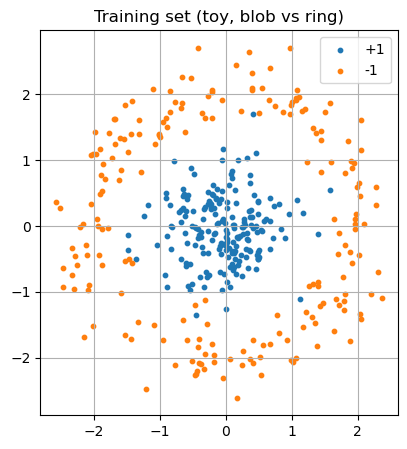

In [4]:
def sample_blob_vs_ring(n_pos=200, n_neg=200, seed=1):
    rng = np.random.default_rng(seed)
    X_pos = rng.normal(loc=0.0, scale=0.55, size=(2, n_pos))
    angle = rng.uniform(0, 2*np.pi, size=n_neg)
    radius = rng.normal(loc=2.1, scale=0.25, size=n_neg)
    X_neg = np.vstack([radius*np.cos(angle), radius*np.sin(angle)]) + rng.normal(0, 0.08, size=(2, n_neg))
    X = np.hstack([X_pos, X_neg])
    y = np.hstack([np.ones(n_pos, dtype=int), -np.ones(n_neg, dtype=int)])
    idx = rng.permutation(y.size)
    return X[:, idx], y[idx]

X, y = sample_blob_vs_ring()
plt.figure(figsize=(5,5))
plt.scatter(X[0, y==1], X[1, y==1], s=10, label="+1")
plt.scatter(X[0, y==-1], X[1, y==-1], s=10, label="-1")
plt.gca().set_aspect("equal")
plt.grid(True)
plt.legend()
plt.title("Training set (toy, blob vs ring)")
plt.show()

## Train and visualize

In [5]:
T = 200
model, wc_err, ub, D_hist = adaboost_linear_directions(X, y, T=T, step_deg=5, seed=0)
print("iterations used:", model["alpha"].size)
print("final train error:", error_rate(y, predict_adaboost_linear(model, X)))

iterations used: 200
final train error: 0.0


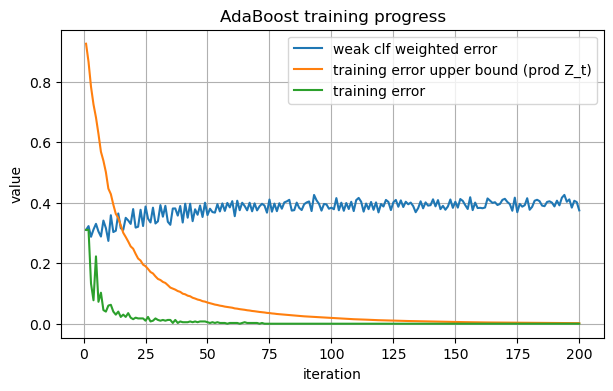

In [6]:
train_errs = []
for t in range(1, model["alpha"].size + 1):
    m_t = {"W": model["W"][:, :t], "b": model["b"][:t], "alpha": model["alpha"][:t], "step_deg": model["step_deg"]}
    train_errs.append(error_rate(y, predict_adaboost_linear(m_t, X)))

plt.figure(figsize=(7,4))
plt.plot(np.arange(1, wc_err.size+1), wc_err, label="weak clf weighted error")
plt.plot(np.arange(1, ub.size+1), ub, label="training error upper bound (prod Z_t)")
plt.plot(np.arange(1, len(train_errs)+1), train_errs, label="training error")
plt.xlabel("iteration")
plt.ylabel("value")
plt.grid(True)
plt.legend()
plt.title("AdaBoost training progress")
plt.show()

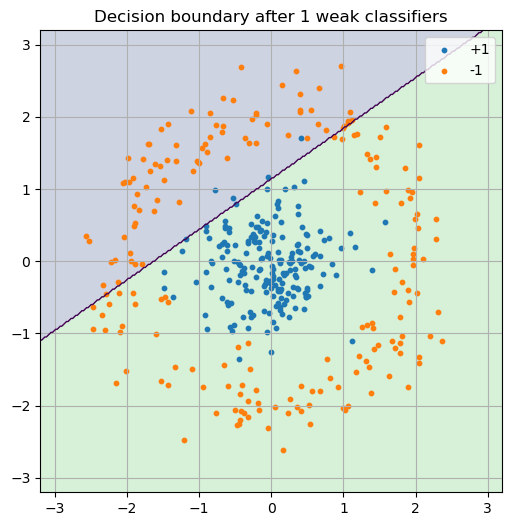

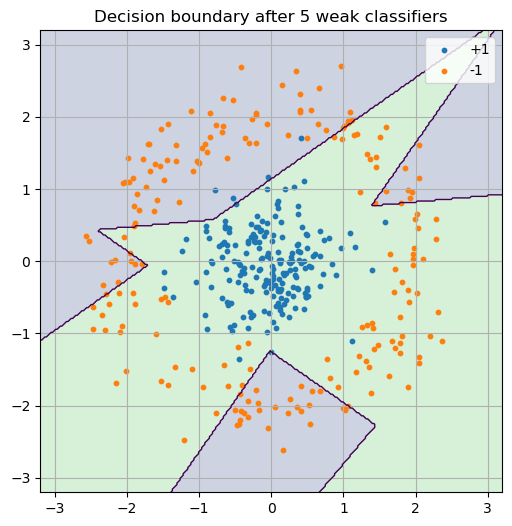

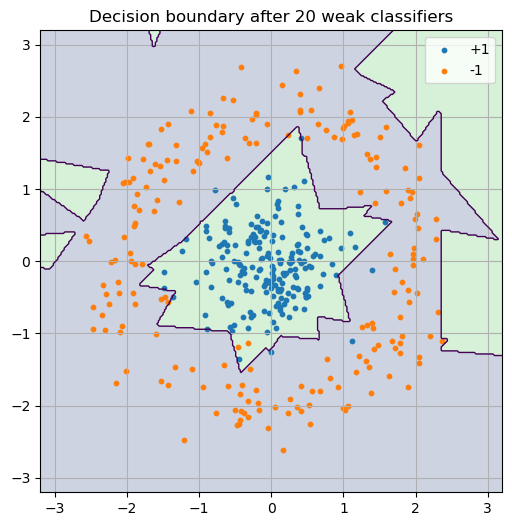

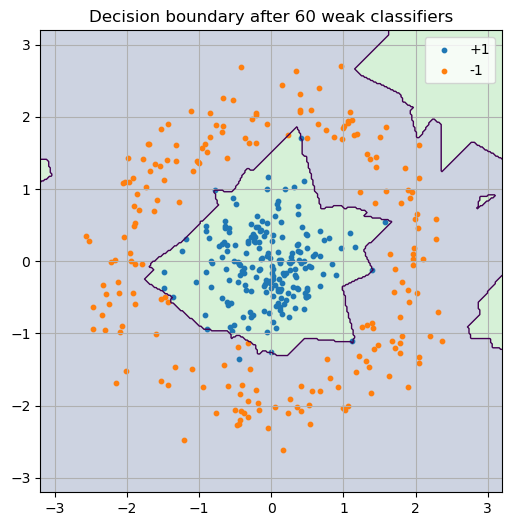

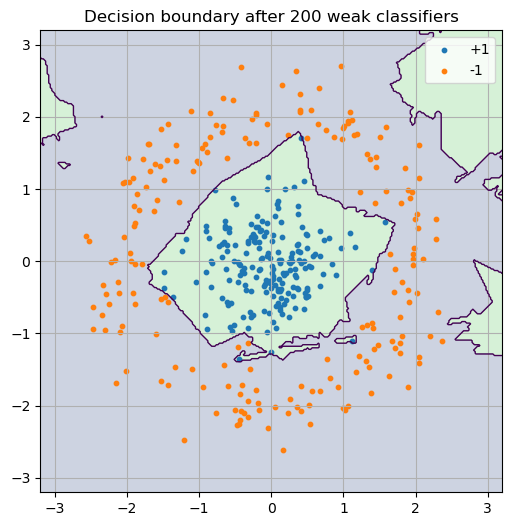

In [7]:
def plot_boundary(model, X, y, lim=3.2, grid=300, title=""):
    xs = np.linspace(-lim, lim, grid)
    ys = np.linspace(-lim, lim, grid)
    xx, yy = np.meshgrid(xs, ys)
    G = np.vstack([xx.ravel(), yy.ravel()])
    pred = predict_adaboost_linear(model, G).reshape(xx.shape)

    plt.figure(figsize=(6,6))
    plt.contourf(xx, yy, pred, levels=[-2,0,2], alpha=0.25)
    plt.contour(xx, yy, pred, levels=[0], linewidths=1)
    plt.scatter(X[0, y==1], X[1, y==1], s=10, label="+1")
    plt.scatter(X[0, y==-1], X[1, y==-1], s=10, label="-1")
    plt.gca().set_aspect("equal")
    plt.grid(True)
    plt.legend()
    plt.title(title)
    plt.show()

for t in [1, 5, 20, 60, model["alpha"].size]:
    m_t = {"W": model["W"][:, :t], "b": model["b"][:t], "alpha": model["alpha"][:t], "step_deg": model["step_deg"]}
    plot_boundary(m_t, X, y, title=f"Decision boundary after {t} weak classifiers")